#Kết nối với Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

df_train = pd.read_csv("/content/drive/MyDrive/CS231/bench_press_train_4.csv")
df_test = pd.read_csv("/content/drive/MyDrive/CS231/bench_press_test_4.csv")
print("Shape:", df_train.shape)
print("Shape:", df_test.shape)
df_train.head()
df_test.head()

Shape: (1374, 119)
Shape: (344, 119)


,L_0,L_1,L_2,L_3,L_4,L_5,L_6,L_7,L_8,L_9,...,dR_20,dR_21,dR_22,dR_23,dR_24,dR_25,dR_26,dR_27,dR_28,label
0,0.925169,0.893149,0.864720,0.856910,0.882096,0.898087,0.933820,0.933518,0.950952,0.954627,...,0.002623,0.004385,0.001390,-0.000970,-0.004160,-0.011364,-0.003820,-0.001842,-0.025589,0
1,0.945150,0.897606,0.883567,0.893521,0.869796,0.900233,0.916664,0.872984,0.831541,0.828566,...,0.012761,0.020145,0.021161,0.014895,0.011708,-0.011171,0.001034,-0.000633,0.001799,0
2,0.908723,0.901268,0.904988,0.864462,0.891842,0.867846,0.851348,0.852883,0.853943,0.856460,...,0.039670,-0.010078,-0.006122,0.003236,0.000900,0.003922,-0.000618,-0.002873,-0.014233,0
3,0.846771,0.807081,0.816567,0.826060,0.806283,0.908853,0.896547,0.865223,0.857944,0.829903,...,0.001019,0.003259,0.008986,0.015934,0.007193,-0.002619,-0.001404,-0.001349,-0.000816,0
4,0.888008,0.921695,0.922354,0.913588,0.914143,0.884944,0.827444,0.928535,0.865504,0.894672,...,0.007300,-0.000268,0.003343,0.000704,0.008638,-0.003282,-0.012425,-0.004288,0.005291,0


#Tách X, y

In [ ]:
X_train = df_train.drop("label", axis=1).values
y_train = df_train["label"].values

X_test = df_test.drop("label", axis=1).values
y_test = df_test["label"].values

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1374, 118)
y_train: (1374,)
X_test: (344, 118)
y_test: (344,)


#Reshape dữ liệu

In [ ]:
import numpy as np
def prepare_lstm_data(X_raw):
    # 1. Tách các thành phần dựa trên file CSV 118 cột
    # 30 cột đầu: Góc trái (L_0 -> L_29)
    # 30 cột kế: Góc phải (R_0 -> R_29)
    # 29 cột kế: Hiệu trái (dL_0 -> dL_28)
    # 29 cột cuối: Hiệu phải (dR_0 -> dR_28)
    X_L = X_raw[:, 0:30]
    X_R = X_raw[:, 30:60]
    X_dL_raw = X_raw[:, 60:89]
    X_dR_raw = X_raw[:, 89:118]
    # 2. Để gộp vào LSTM (30 steps), ta cần bù 1 giá trị 0 vào đầu các mảng hiệu số
    # (Vì frame đầu tiên không có frame trước đó để tính hiệu)
    X_dL = np.column_stack([np.zeros(X_dL_raw.shape[0]), X_dL_raw])
    X_dR = np.column_stack([np.zeros(X_dR_raw.shape[0]), X_dR_raw])
    # 3. Gộp theo trục cuối (axis=-1) để tạo thành 4 features tại mỗi timestep
    # Kết quả mong muốn: (n_samples, 30, 4)
    X_stacked = np.stack([X_L, X_R, X_dL, X_dR], axis=-1)
    return X_stacked
# --- ÁP DỤNG CHO TRAIN ---
X_train_raw = df_train.drop("label", axis=1).values
y_train = df_train["label"].values
X_train = prepare_lstm_data(X_train_raw)
print("Kích thước X_train sau khi gộp:", X_train.shape)
# Phải là: (n_samples, 30, 4)
# --- ÁP DỤNG CHO TEST ---
X_test_raw = df_test.drop("label", axis=1).values
y_test = df_test["label"].values
X_test = prepare_lstm_data(X_test_raw)
print("Kích thước X_test sau khi gộp:", X_test.shape)
# Phải là: (n_samples, 30, 4)

Kích thước X_train sau khi gộp: (1374, 30, 4)
Kích thước X_test sau khi gộp: (344, 30, 4)


#K-Fold

In [ ]:
from sklearn.model_selection import StratifiedKFold

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#LSTM baseline

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
def create_model():
    model = Sequential([
        # Sử dụng 1 lớp LSTM 32 units (đủ cho dữ liệu nhỏ)
        LSTM(32, input_shape=(30, 4)),
        # Thêm Dropout để giảm dao động răng cưa như biểu đồ bạn gửi
        Dropout(0.2),
        # Lớp trung gian
        Dense(16, activation='relu'),
        # Lớp đầu ra cho 4 nhãn
        Dense(4, activation='softmax')
    ])
    #Khởi tạo đối tượng Adam với learning_rate cụ thể
    opt = Adam(learning_rate=0.0005)
    model.compile(
        optimizer=opt,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

#Train

In [ ]:
from sklearn.metrics import accuracy_score
fold = 1
acc_scores = []
best_model = None
best_acc = 0.0

for train_idx, val_idx in kf.split(X_train, y_train):
    X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

    model = create_model()

    # Tăng epochs lên một chút vì dữ liệu thô cần thời gian hội tụ hơn
    model.fit(X_train_fold, y_train_fold,
              validation_data=(X_val_fold, y_val_fold),
              epochs=50, batch_size=16, verbose=0)

    y_pred_val = np.argmax(model.predict(X_val_fold), axis=1)
    acc = accuracy_score(y_val_fold, y_pred_val)
    print(f"Fold {fold} Accuracy: {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        best_model = model

    acc_scores.append(acc)
    fold += 1

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
Fold 1 Accuracy: 0.9455


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Fold 2 Accuracy: 0.9745


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Fold 3 Accuracy: 0.9636


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Fold 4 Accuracy: 0.8727


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Fold 5 Accuracy: 0.9745


#Kiểm tra với tập test

In [ ]:
# --- KẾT QUẢ CUỐI CÙNG ---
print("\n" + "="*30)
print(f"Mean Validation Accuracy: {np.mean(acc_scores):.4f}")
print(f"Best Validation Accuracy: {best_acc:.4f}")

# Đánh giá trên tập TEST ĐỘC LẬP (X_test đã chuẩn hóa sẵn trong CSV)
if best_model is not None:
    print("\n--- ĐÁNH GIÁ TRÊN TẬP TEST (UNSEEN DATA) ---")
    y_pred_test = np.argmax(best_model.predict(X_test), axis=1)
    final_test_acc = accuracy_score(y_test, y_pred_test)
    print(f"Final Test Accuracy: {final_test_acc:.4f}")

    # Chỉ cần lưu Model .h5
    # Lưu chính xác định dạng H5 cũ
    best_model.export("/content/drive/MyDrive/CS231/bench_press_final_model")
    print("\nĐã lưu Model tốt nhất vào Drive thành công!")


Mean Validation Accuracy: 0.9462
Best Validation Accuracy: 0.9745

--- ĐÁNH GIÁ TRÊN TẬP TEST (UNSEEN DATA) ---
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Final Test Accuracy: 0.8692
Saved artifact at '/content/drive/MyDrive/CS231/bench_press_final_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30, 4), dtype=tf.float32, name='keras_tensor_5')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  136237047265040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136237047264272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136237047266192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136237047266000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136237047261008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136237047266384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136237047265424: TensorSpec(shape=(), dtype=tf.resource, name=None)

Đã lưu Model

#Đánh giá

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


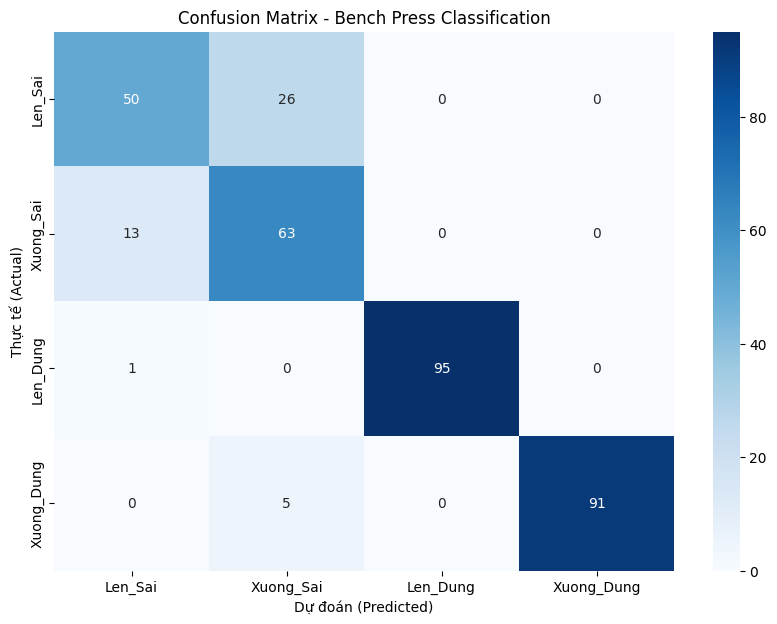


--- CHI TIẾT ĐÁNH GIÁ (CLASSIFICATION REPORT) ---
              precision    recall  f1-score   support

     Len_Sai       0.78      0.66      0.71        76
   Xuong_Sai       0.67      0.83      0.74        76
    Len_Dung       1.00      0.99      0.99        96
  Xuong_Dung       1.00      0.95      0.97        96

    accuracy                           0.87       344
   macro avg       0.86      0.86      0.86       344
weighted avg       0.88      0.87      0.87       344



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Dự đoán trên tập Test bằng model tốt nhất
y_pred_test = np.argmax(best_model.predict(X_test), axis=1)

# 2. Tạo Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)

# Định nghĩa tên các nhãn (Thay đổi theo đúng thứ tự nhãn của bạn)
# Ví dụ: 0: Correct, 1: Too shallow, 2: Elbows flared, 3: Too fast
# Thứ tự bắt buộc phải là: 0, 1, 2, 3
target_names = ["Len_Sai", "Xuong_Sai", "Len_Dung", "Xuong_Dung"]

# 3. Vẽ biểu đồ Confusion Matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.title('Confusion Matrix - Bench Press Classification')
plt.show()

# 4. In Classification Report
print("\n--- CHI TIẾT ĐÁNH GIÁ (CLASSIFICATION REPORT) ---")
print(classification_report(y_test, y_pred_test, target_names=target_names))